## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split,cross_val_score, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [2]:
Insurance_df = pd.read_csv(r"C:\Users\91735\OneDrive\Documents\Insur_Cost_Pred\Data\datasets_13720_18513_insurance(1).csv")

In [3]:
Insurance_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## Understanding the Structure of Dataset

In [4]:
Insurance_df.shape

(1338, 7)

In [5]:
Insurance_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
Insurance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
Insurance_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Check the Missing Values

In [8]:
Insurance_df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

#### Hence It seems to be No Missing Values Present in the Dataset

## Univariate Analysis for Numerical Features

In [9]:
Num_Cols = ["age","bmi","children","charges"]

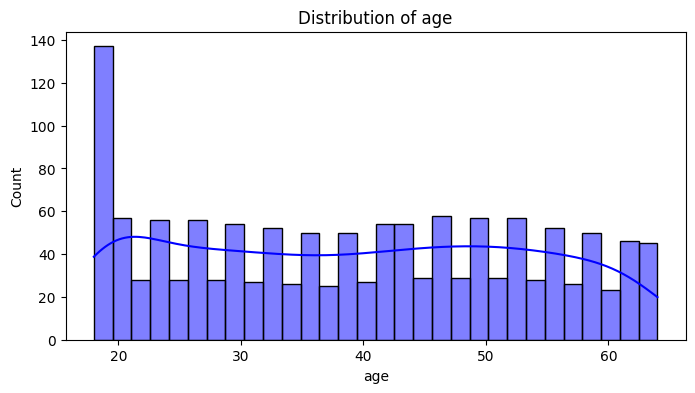

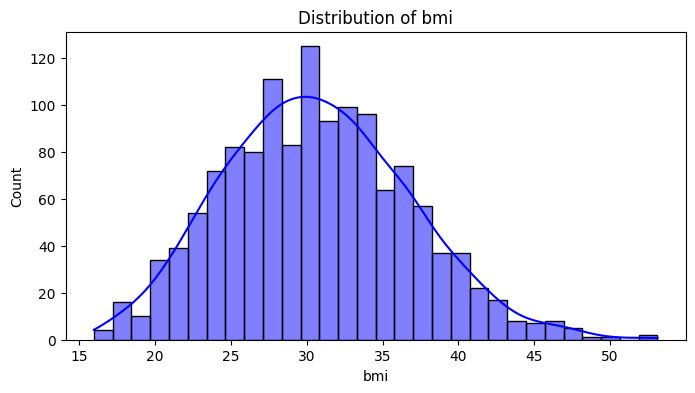

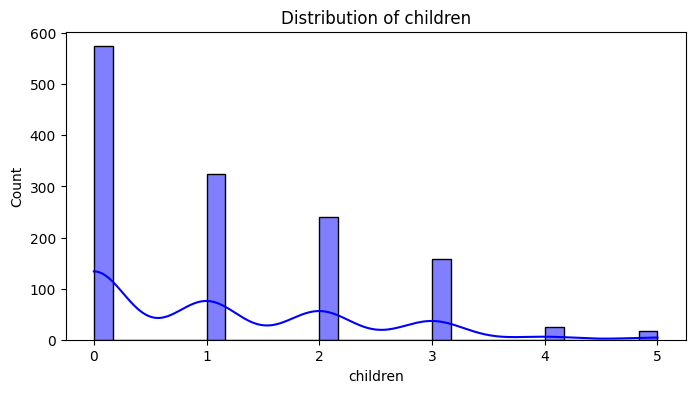

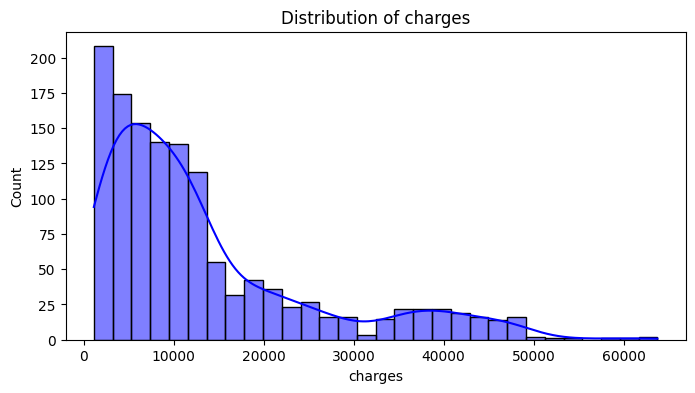

In [10]:
# Plot distribution plots
for col in Num_Cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(Insurance_df[col], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

## Univariate Analysis for Categorical Features

In [11]:
Cat_Cols =  ["sex", "smoker", "region"]

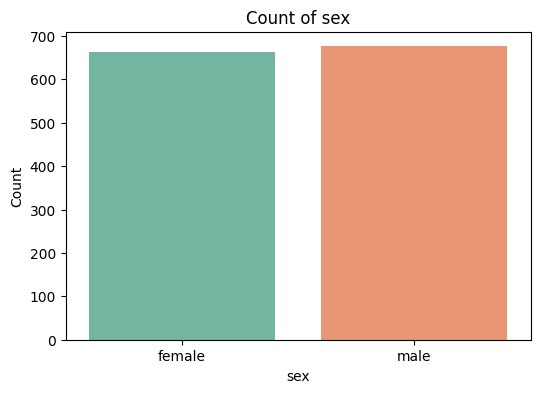

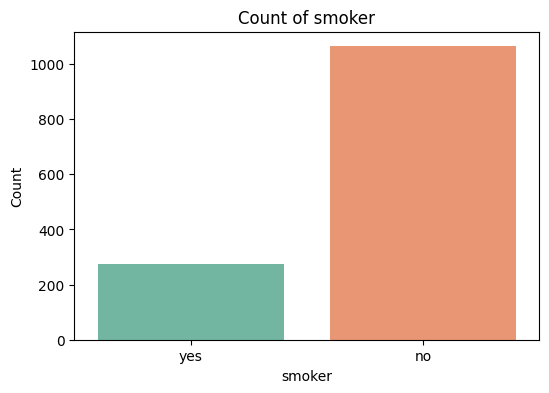

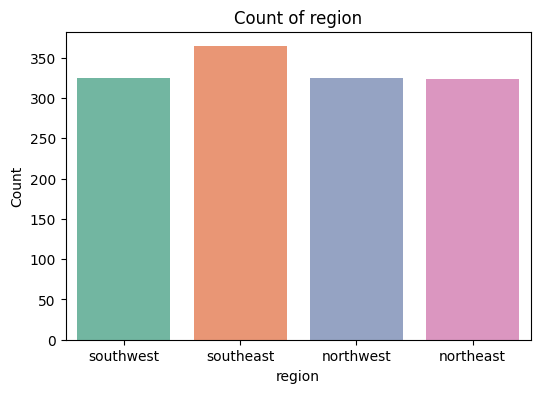

In [12]:
# Count plots for each
for col in Cat_Cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=Insurance_df, x=col, palette='Set2')
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()


## Bivariate Analysis for Numerical Features

In [13]:
Num_features = ['age', 'bmi', 'children']

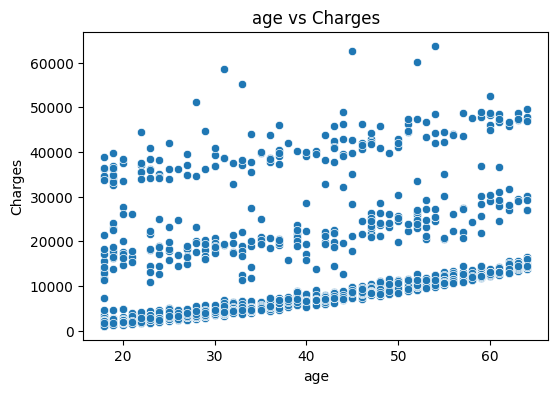

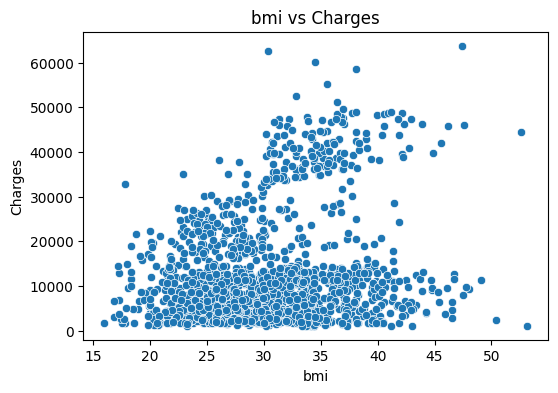

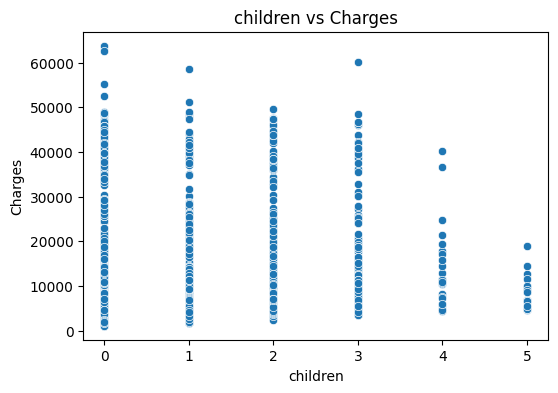

In [14]:
for feature in Num_features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=Insurance_df[feature], y=Insurance_df['charges'])
    plt.title(f'{feature} vs Charges')
    plt.xlabel(feature)
    plt.ylabel('Charges')
    plt.show()


## Bivariate Analysis for Categorical Features

In [15]:
Cat_features =  ["sex", "smoker", "region"]

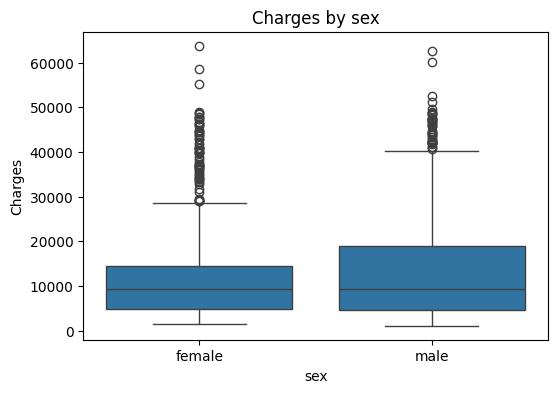

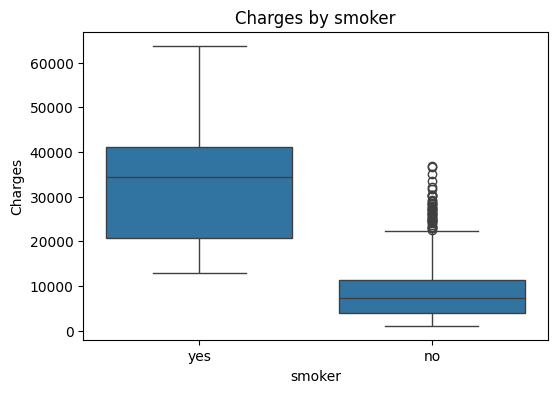

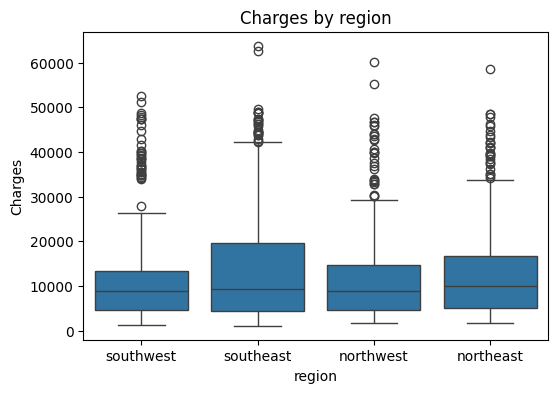

In [16]:
for feature in Cat_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=Insurance_df[feature], y=Insurance_df['charges'])
    plt.title(f'Charges by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Charges')
    plt.show()


## Check the Distribution of Categorical Data

In [17]:
print(Insurance_df.sex.value_counts())

sex
male      676
female    662
Name: count, dtype: int64


In [18]:
print(Insurance_df.smoker.value_counts())

smoker
no     1064
yes     274
Name: count, dtype: int64


In [19]:
print(Insurance_df.region.value_counts())

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


## Encoding the Categorical Data

In [20]:
Insurance_df.replace({"sex":{"male":0,"female":1}},inplace = True)

In [21]:
Insurance_df.replace({"smoker":{"no":0,"yes":1}},inplace = True)

In [22]:
Insurance_df.replace({"region":{"southeast":1,"southwest":2,"northwest":3,"northeast":4}},inplace = True)

#### Now all the columns in the Dataset are Numerical

## Correlation Heatmap

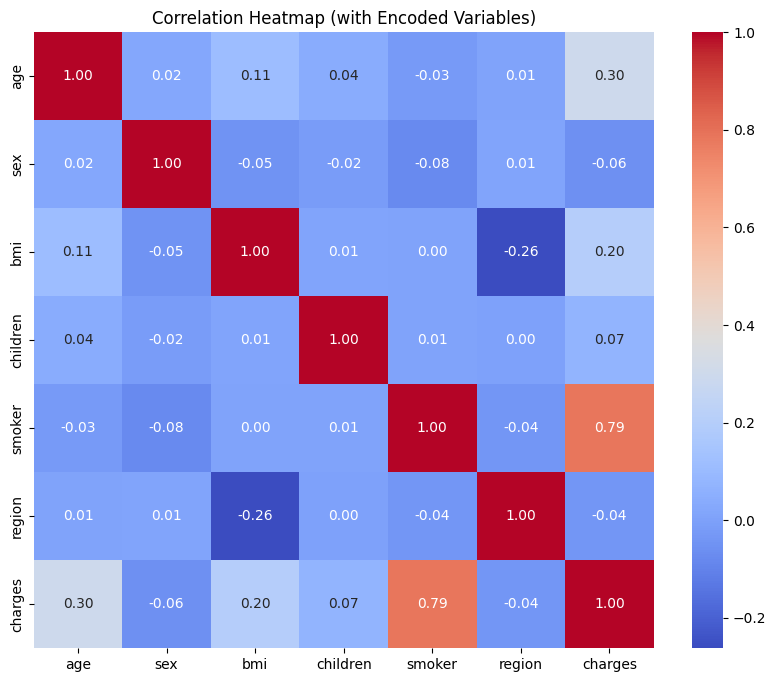

In [23]:
# Correlation matrix with encoded features
plt.figure(figsize=(10, 8))
sns.heatmap(Insurance_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (with Encoded Variables)')
plt.show()


## Identify the Outliers

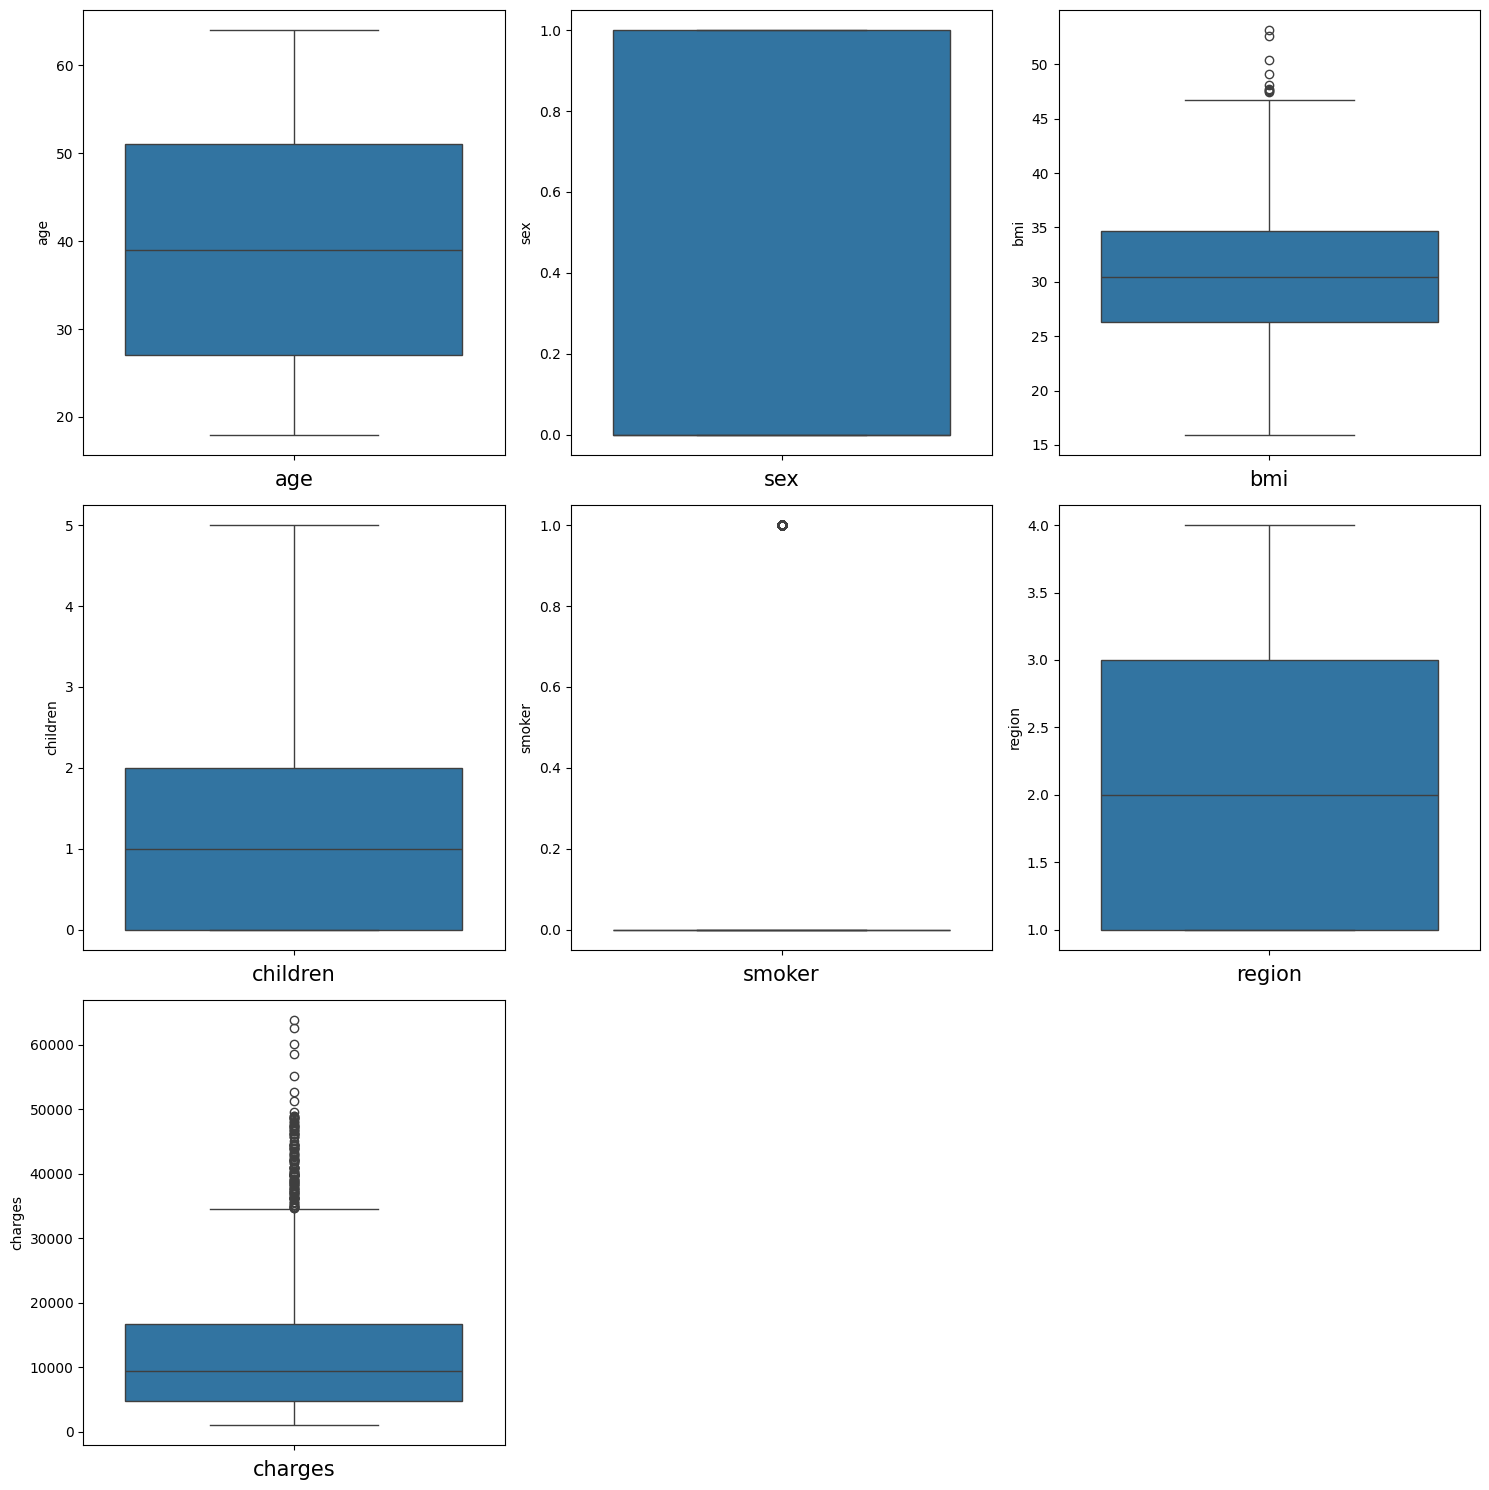

In [24]:
plt.figure(figsize=(15,15),facecolor="white")

plotnumber = 1
for column in Insurance_df:
    if plotnumber<=36:
        ax=plt.subplot(3,3,plotnumber)
        sns.boxplot(Insurance_df[column])
        plt.xlabel(column,fontsize=15)
    plotnumber+=1
plt.tight_layout()

### 1. bmi

In [25]:
IQR_bmi = Insurance_df["bmi"].quantile(0.75)-Insurance_df["bmi"].quantile(0.25)
Upper_Limit_IQR_bmi = Insurance_df["bmi"].quantile(0.75) + 1.5*IQR_bmi 
Upper_Limit_IQR_bmi

np.float64(47.290000000000006)

<Axes: ylabel='bmi'>

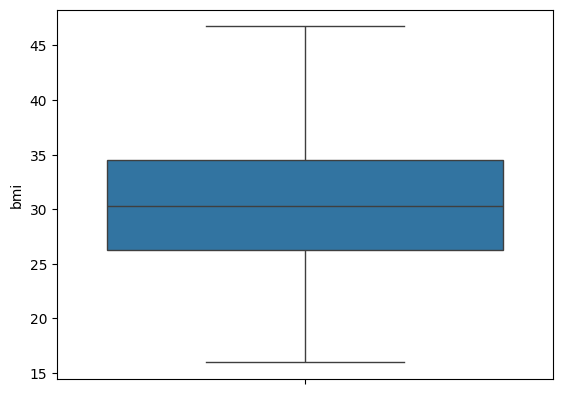

In [26]:
bmi_OUTR = Insurance_df[Insurance_df["bmi"] < Upper_Limit_IQR_bmi]
sns.boxplot(bmi_OUTR["bmi"])

### 2. charges

In [27]:
IQR_charges = Insurance_df["charges"].quantile(0.75)-Insurance_df["charges"].quantile(0.25)
Upper_Limit_IQR_charges = Insurance_df["charges"].quantile(0.75) + 1.5*IQR_charges
Upper_Limit_IQR_charges

np.float64(34489.350562499996)

<Axes: ylabel='charges'>

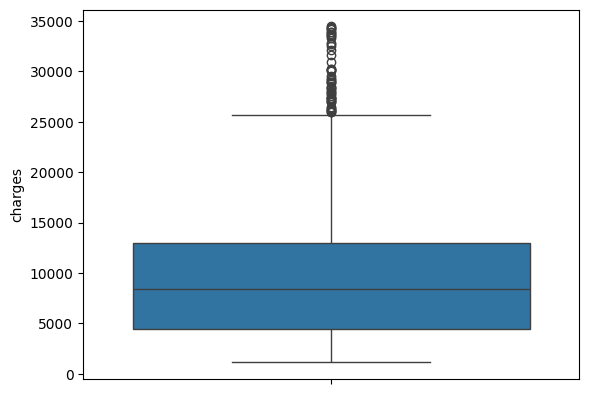

In [28]:
charges_OUTR = Insurance_df[Insurance_df["charges"] < Upper_Limit_IQR_charges]
sns.boxplot(charges_OUTR["charges"])

In [29]:
print("Original shape:", Insurance_df.shape)
print("After removing outliers:", charges_OUTR.shape)


Original shape: (1338, 7)
After removing outliers: (1199, 7)


## Spliting the Data and Target Variables

In [30]:
X = Insurance_df.drop(["charges"],axis = 1)
y = Insurance_df["charges"]

In [31]:
X

,age,sex,bmi,children,smoker,region
0,19,1,27.900,0,1,2
1,18,0,33.770,1,0,1
2,28,0,33.000,3,0,1
3,33,0,22.705,0,0,3
4,32,0,28.880,0,0,3
...,...,...,...,...,...,...
1333,50,0,30.970,3,0,3
1334,18,1,31.920,0,0,4
1335,18,1,36.850,0,0,1
1336,21,1,25.800,0,0,2


In [32]:
y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

## Splitting Training and Test Data¶

In [33]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.1,random_state = 2)

In [34]:
# Scale the features
scaler_X = StandardScaler()
scaler_y = StandardScaler()

In [35]:
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

In [36]:
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

## Model Training

### 1. Linear Regression Model

In [37]:
# Train Linear Regression model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [38]:
# Predict on test set
y_pred = lr.predict(X_test_scaled)

In [39]:
# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [40]:
# Print results
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 4047.70
Mean Squared Error (MSE): 33717109.82
Root Mean Squared Error (RMSE): 5806.64
R² Score: 0.7059


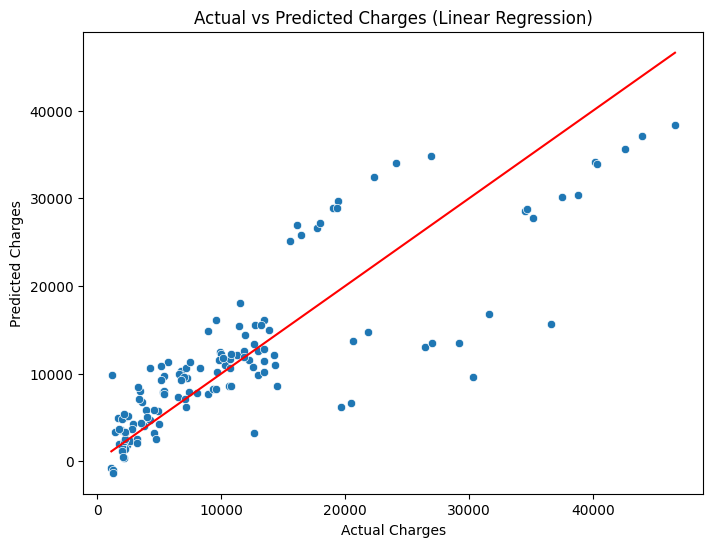

In [41]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges (Linear Regression)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.show()


### 2. Decision Tree Regressor

In [42]:
# Initialize and train Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [43]:
# Predict on test set
y_pred = dt.predict(X_test)

In [44]:
# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [45]:
# Print results
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 2959.92
Mean Squared Error (MSE): 41594662.21
Root Mean Squared Error (RMSE): 6449.39
R² Score: 0.6372


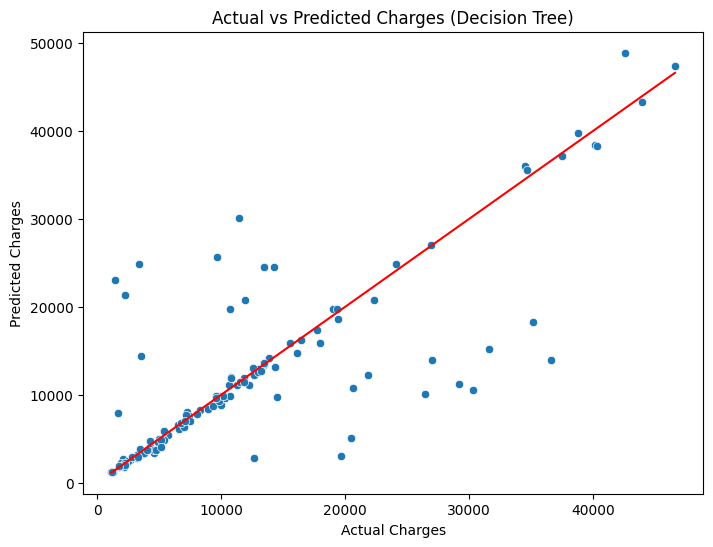

In [46]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges (Decision Tree)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.show()


## 3. Random Forest Regressor

In [47]:
# Initialize and train Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [48]:
# Predict on test set
y_pred = rf.predict(X_test)

In [49]:
# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [50]:
# Print results
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 2944.32
Mean Squared Error (MSE): 29164000.26
Root Mean Squared Error (RMSE): 5400.37
R² Score: 0.7456


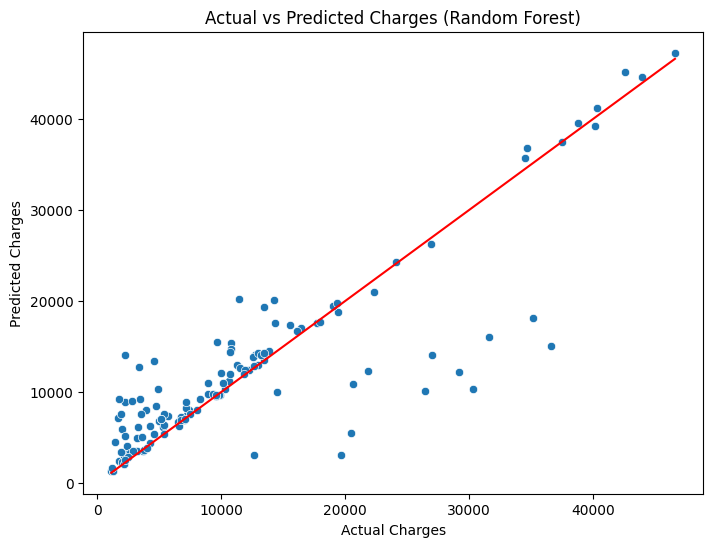

In [51]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges (Random Forest)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.show()


### 4. XGBoost Regressor

In [52]:
# Initialize the XGBoost regressor
model = xgb.XGBRegressor(objective='reg:squarederror', 
                         n_estimators=100, 
                         learning_rate=0.1, 
                         max_depth=5)

In [53]:
# Train the model
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [54]:
# Make predictions
y_pred = model.predict(X_test)

In [55]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [56]:
# Print the evaluation metrics
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R² Score: {r2}")

Root Mean Squared Error (RMSE): 5014.612596282974
Mean Absolute Error (MAE): 2728.7638383229364
R² Score: 0.7806590317804378


## Cross Validation of Models

In [57]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(),
    'Random Forest Regressor': RandomForestRegressor(),
    'XGBoost Regressor': xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5)
}

In [58]:
def evaluate_model(model, X, y):
    cv_results = cross_validate(model, X, y, cv=5, 
                                scoring=('neg_mean_absolute_error', 'neg_mean_squared_error', 'r2'))
    
    mae_scores = -cv_results['test_neg_mean_absolute_error']
    mse_scores = -cv_results['test_neg_mean_squared_error']
    r2_scores = cv_results['test_r2']
    
    mean_mae = mae_scores.mean()
    std_mae = mae_scores.std()
    mean_mse = mse_scores.mean()
    std_mse = mse_scores.std()
    mean_rmse = np.sqrt(mse_scores).mean()
    std_rmse = np.sqrt(mse_scores).std()
    mean_r2 = r2_scores.mean()
    std_r2 = r2_scores.std()
    
    print(f"\n{model.__class__.__name__} - Cross-Validation Results:")
    print(f"MAE: Mean = {mean_mae:.2f}, Std = {std_mae:.2f}")
    print(f"MSE: Mean = {mean_mse:.2f}, Std = {std_mse:.2f}")
    print(f"RMSE: Mean = {mean_rmse:.2f}, Std = {std_rmse:.2f}")
    print(f"R²: Mean = {mean_r2:.4f}, Std = {std_r2:.4f}")

# Run evaluation for all models
for name, model in models.items():
    evaluate_model(model, X_train, y_train)


LinearRegression - Cross-Validation Results:
MAE: Mean = 4231.04, Std = 255.81
MSE: Mean = 37590511.08, Std = 4754338.30
RMSE: Mean = 6119.31, Std = 380.21
R²: Mean = 0.7400, Std = 0.0626

DecisionTreeRegressor - Cross-Validation Results:
MAE: Mean = 2908.21, Std = 344.83
MSE: Mean = 39492541.30, Std = 6889400.07
RMSE: Mean = 6260.66, Std = 544.72
R²: Mean = 0.7300, Std = 0.0600

RandomForestRegressor - Cross-Validation Results:
MAE: Mean = 2564.14, Std = 202.06
MSE: Mean = 23144999.61, Std = 4112334.78
RMSE: Mean = 4793.34, Std = 411.00
R²: Mean = 0.8396, Std = 0.0457

XGBRegressor - Cross-Validation Results:
MAE: Mean = 2590.68, Std = 178.61
MSE: Mean = 22821910.64, Std = 4655901.58
RMSE: Mean = 4755.25, Std = 457.73
R²: Mean = 0.8409, Std = 0.0514


## Hyperparameter Tuning for  Random Forest Regressor

In [59]:
rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Initialize model
rf = RandomForestRegressor(random_state=42)

# Randomized search
rf_random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=50,
    cv=5,
    verbose=1,
    n_jobs=-1,
    scoring='neg_mean_squared_error'
)

# Fit model
rf_random_search.fit(X_train, y_train)

print("Best Random Forest Params:", rf_random_search.best_params_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Random Forest Params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}


## Hyperparameter Tuning for XGB Regressor

In [ ]:
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5]
}

# Initialize model
xgb = XGBRegressor(random_state=42)

# Randomized search
xgb_random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=50,
    cv=5,
    verbose=1,
    n_jobs=-1,
    scoring='neg_mean_squared_error'
)

# Fit model
xgb_random_search.fit(X_train, y_train)

print("Best XGBoost Params:", xgb_random_search.best_params_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits


In [ ]:
best_rf_model = rf_random_search.best_estimator_
best_xgb_model = xgb_random_search.best_estimator_

## Cross Validation Tuned Models

In [ ]:
def evaluate_models(models, X, y, cv=5):
    results = []

    for name, model in models.items():
        scores = cross_validate(model, X, y,
                                scoring=['neg_mean_absolute_error',
                                         'neg_mean_squared_error',
                                         'r2'],
                                cv=cv, return_train_score=False)

        mae = -np.mean(scores['test_neg_mean_absolute_error'])
        mse = -np.mean(scores['test_neg_mean_squared_error'])
        rmse = np.sqrt(mse)
        r2 = np.mean(scores['test_r2'])

        results.append({
            'Model': name,
            'MAE': round(mae, 2),
            'MSE': round(mse, 2),
            'RMSE': round(rmse, 2),
            'R²': round(r2, 4)
        })

    return pd.DataFrame(results).sort_values(by="RMSE")


In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(),
    'Tuned Random Forest': rf_random_search.best_estimator_,
    'Tuned XGBoost': xgb_random_search.best_estimator_
}

results_df = evaluate_models(models, X_train, y_train)
print(results_df)


Hence Tuned XGB Regressor performed Better with Respect to other Models

# Insurance Cost Prediction Report

## Introduction

The goal of this project is to build a predictive model that estimates insurance charges based on customer demographic and health-related data.

## Data Preparation

### Importing Libraries

Essential Python libraries such as pandas, numpy, seaborn, and matplotlib were imported for data manipulation and visualization.

### Loading the Dataset

The dataset was loaded into a pandas DataFrame, and initial checks were performed to understand its structure.

### Checking Missing Values

In the Dataset There were No Missing Values Present.

## Data Exploration

### Understanding Data Structure

The dataset includes features such as:
age, sex, bmi, children, smoker, and region
Target variable: charges (insurance cost)

## Univariate Analysis

Distribution plots used for numerical features (age, bmi, children, charges),Count plots for categorical features (sex, smoker, region).

## Bivariate Analysis

Relationships between charges and other features were visualized using scatter and box plots.,Clear trends were observed, especially higher charges for smokers.

##  Feature Engineering:

**Encoding:** Label encoding is likely applied to categorical variables.

**Scaling:** StandardScaler applied to normalize feature ranges.

**Train-Test Split:** Dataset divided into training and test sets.



## Correlation Analysis

The most influential variables with respect to insurance charges are:
**Smoker status (strongest)**,
**Age**, and
**BMI**.

**Sex**,**Children**, and **Region** show weak or Negligible Correlation 

##  Data Preprocessing

The dataset was split into features and target.
StandardScaler was applied to standardize feature ranges.
The data was split into training and testing sets.

### Identifying Outliers

Outliers were detected in variables like bmi,charges likely handled implicitly before modeling.

## Model Training and Evaluation

#### Linear Regression   
#### Decision Tree Regressor
#### Random Forest Regressor
#### XGBoost Regressor

## Each model's performance was evaluated based on:

#### Mean Absolute Error (MAE)
#### Mean Squared Error (MSE)
#### Root Mean Squared Error (RMSE)
#### R² Score

## Cross-Validation

5-fold cross-validation was performed.

**Random Forest Regressor Model** has achieved the best Mean R2 Score of **84.09%**, making it the most reliable model among those tested.

## Hyperparameter Tuning for Random Forest Regressor and XGBoost Regressor

Grid search with 5-fold cross-validation across 50 hyperparameter combinations (totaling 250 fits) identified the best Random Forest model with `**n_estimators=500, min_samples_split=2, min_samples_leaf=2, max_features='sqrt, and max_depth=10**, achieving optimal performance on the training data.

Using 5-fold cross-validation over 50 hyperparameter combinations (totaling 250 fits), the best XGBoost model was found with **subsample=0.8, n_estimators=300, max_depth=3, learning_rate=0.01, gamma=0.1, and`colsample_bytree=1.0**, indicating a well-regularized and balanced model suitable for preventing overfitting while maintaining strong predictive performance.


## Cross Validation For Tuned Models

Among all Evaluated Models, **Tuned XGBoost** achieved the best performance with the lowest **MAE (2590.49), MSE (20,171,001.93), and RMSE (4491.21)**, along with the highest **R² score (0.8599)**, indicating strong predictive accuracy and generalization. Tuned Random Forest followed closely, while Linear Regression and Decision Tree performed worse.

## Challenges Faced

**1.Handling Outliers:**

Outliers in variables like BMI and charges required careful treatment to avoid skewing model performance.

**2.Feature Scaling:**

Ensuring consistent feature scaling (using StandardScaler) was essential, especially for models sensitive to feature ranges.

**3.Model Overfitting:**

Preventing overfitting, particularly in complex models like Random Forest and XGBoost, required extensive hyperparameter tuning and validation.

**4.Hyperparameter Tuning:**

Performing grid search with 5-fold cross-validation across multiple combinations was computationally intensive and time-consuming.

**5.Model Selection:**

Choosing the best-performing model required balancing multiple evaluation metrics and understanding trade-offs between complexity and accuracy.



## Conclusion 

The XGBoost model, after hyperparameter tuning, delivered the best performance in predicting insurance costs, with the lowest error metrics and highest **R² score (0.8599)**. This confirms that **XGBoost is the most accurate and reliable model among those tested**.